# Deteccion de Objetos con RF-DETR

La deteccion de objetos es una tarea fundamental en vision artificial. Consiste en encontrar objetos en imagenes y dibujar cajas alrededor de ellos (bounding boxes) indicando que objeto es.

**Diferencia con clasificacion:**
- Clasificacion: "Esta imagen completa contiene un gato" → 1 etiqueta
- Deteccion: "Hay 3 gatos en las posiciones X, Y, Z" → multiples boxes con etiquetas

En este notebook veremos RF-DETR, un detector moderno basado en Transformers.

## Evolucion de los Detectores

### Arquitecturas Clasicas (CNN):
- **R-CNN, Fast R-CNN, Faster R-CNN**: Detectores en dos etapas (propuestas + clasificacion)
- **YOLO (You Only Look Once)**: Detector en una etapa, muy rapido
  - YOLOv3, YOLOv4, YOLOv5, YOLOv235894... (muchas versiones)
  - Ventaja: velocidad (tiempo real en video)
  - Desventaja: arquitectura compleja con muchos "trucos", LICENCIA!!

### Arquitecturas Modernas (Transformers):
- **DETR (DEtection TRansformer)**: Primer detector con Transformers
- **RT-DETR / RF-DETR**: Version rapida y eficiente de DETR
  - Ventaja: arquitectura limpia, sin anchors ni NMS
  - Ventaja: precision SOTA (State of the Art), LICENCIAS 

**Por que Transformers?** Los Transformers (la misma arquitectura de ChatGPT) tambien funcionan muy bien en vision. Son mas flexibles y aprenden mejor las relaciones entre objetos.

## Configuracion e Imports

In [13]:
# Instalar libreria RFDETR (roboflow DETR)
try:
    from rfdetr import RFDETRMedium
    print("RFDETR importado!")
except ImportError:
    print("Instalando rfdetr...")
    %pip install rfdetr
    from rfdetr import RFDETRMedium
import torch
torch.cuda.empty_cache()
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO
import sys
from pathlib import Path
import logging
logging.getLogger().setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore") # evitar warnings innecesarios

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch version: {torch.__version__}, usando: {device}")

RFDETR importado!
torch version: 2.6.0+cu124, usando: cuda


## Carga del Modelo RF-DETR

RF-DETR tiene varios tamaños: l (large), m (medium), s (small), x (extra large). Usaremos `rtdetr-l.pt` que da buen balance.

El modelo viene pre-entrenado en **COCO dataset** con **80 categorias** de objetos comunes: personas, coches, animales, muebles, electronica, etc.

In [14]:
coco_model = RFDETRMedium()

coco_model.optimize_for_inference(compile=False)

print("Modelo RF-DETR cargado")
print(f"Clases disponibles: {len(coco_model.class_names)} categorias COCO")

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Modelo RF-DETR cargado
Clases disponibles: 80 categorias COCO


## Carga de Imagenes de Ejemplo

In [15]:
# Cargar imagenes desde GitHub
url_cars = "https://github.com/sergiovillanueva/Modelos_Fundacionales/raw/main/assets/cars.jpg"
image_cars = Image.open(BytesIO(requests.get(url_cars).content)).convert("RGB")

url_person = "https://github.com/sergiovillanueva/Modelos_Fundacionales/raw/main/assets/person_cars.jpg"
image_person = Image.open(BytesIO(requests.get(url_person).content)).convert("RGB")

url_bananas = "https://github.com/sergiovillanueva/Modelos_Fundacionales/raw/main/assets/bananas.jpg"
image_bananas = Image.open(BytesIO(requests.get(url_bananas).content)).convert("RGB")

print("Imagenes cargadas")

Imagenes cargadas


## Deteccion de Objetos

Vamos a detectar objetos en las imagenes. RF-DETR devolvera:
- **Bounding boxes**: coordenadas [x1, y1, x2, y2]
- **Clases**: que objeto es (coche, persona, etc.)
- **Confianza**: probabilidad de 0 a 1


Detectados 10 objetos:

  person: 0.97 en [364, 86, 487, 327]
  car: 0.95 en [200, 110, 361, 203]
  car: 0.94 en [7, 114, 149, 212]
  car: 0.92 en [113, 107, 206, 179]
  car: 0.77 en [0, 115, 31, 186]
  car: 0.73 en [513, 94, 571, 119]
  car: 0.70 en [58, 103, 125, 122]
  car: 0.68 en [20, 102, 67, 117]
  handbag: 0.54 en [439, 129, 486, 255]
  car: 0.51 en [493, 97, 523, 117]


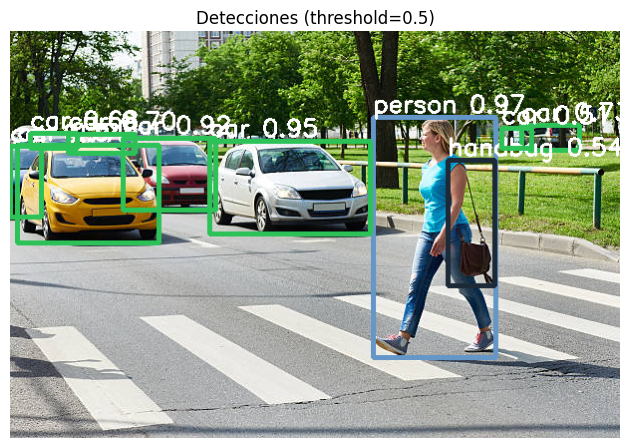

In [18]:
def detect_objects(image, model, conf_threshold=0.5):
    """Detecta objetos usando RF-DETR"""
    
    # Convertir PIL a numpy
    img_array = np.array(image)
    
    detections = model.predict(img_array, threshold=conf_threshold)
    # Obtener detecciones desde la estructura Detections
    
    print(f"\nDetectados {len(detections.xyxy)} objetos:\n")
    
    # Dibujar detecciones
    img_result = img_array.copy()
    
    for box, cls, score in zip(detections.xyxy, detections.class_id, detections.confidence):
        x1, y1, x2, y2 = map(int, box)
        class_name = model.class_names[int(cls)]
        
        print(f"  {class_name}: {score:.2f} en [{x1}, {y1}, {x2}, {y2}]")
        
        # Dibujar box y texto
        cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 0, 255), 3)
        color = ((int(cls) * 100) % 256, (int(cls) * 150) % 256, (int(cls) * 200) % 256)
        cv2.rectangle(img_result, (x1, y1), (x2, y2), color, 3)
        text = f"{class_name} {score:.2f}"
        cv2.putText(img_result, text, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    
    # Visualizar
    
    plt.imshow(img_result)
    plt.title(f"Detecciones (threshold={conf_threshold})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Ejemplo: detectar coches
# detect_objects(image_cars, coco_model)
detect_objects(image_person, coco_model)


## Experimentar con Thresholds

El threshold de confianza controla cuantas detecciones vemos:
- **Threshold alto (0.7-0.9)**: Solo detecciones muy seguras, menos false positives (mejor precisión)
- **Threshold bajo (0.2-0.4)**: Mas detecciones, pero puede haber errores (mejor recall)

Puedes probar con diferentes valores:


Detectados 10 objetos:

  person: 0.97 en [364, 86, 487, 327]
  car: 0.95 en [200, 110, 361, 203]
  car: 0.94 en [7, 114, 149, 212]
  car: 0.92 en [113, 107, 206, 179]
  car: 0.77 en [0, 115, 31, 186]
  car: 0.73 en [513, 94, 571, 119]
  car: 0.70 en [58, 103, 125, 122]
  car: 0.68 en [20, 102, 67, 117]
  handbag: 0.54 en [439, 129, 486, 255]
  car: 0.51 en [493, 97, 523, 117]


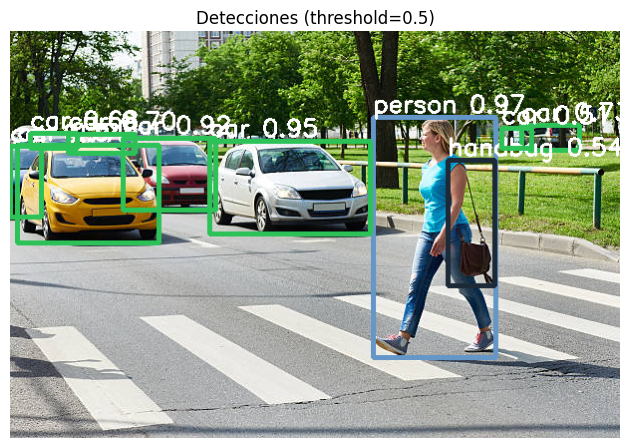

In [21]:
detect_objects(image_person, coco_model, conf_threshold=0.5)

## Ver todas las clases COCO

Veamos que objetos puede detectar el modelo:

In [22]:
# Mostrar todas las clases disponibles
print("Clases COCO que RF-DETR puede detectar:\n")
for idx, name in coco_model.class_names.items():
    print(f"{idx:2d}: {name}")

Clases COCO que RF-DETR puede detectar:

 1: person
 2: bicycle
 3: car
 4: motorcycle
 5: airplane
 6: bus
 7: train
 8: truck
 9: boat
10: traffic light
11: fire hydrant
13: stop sign
14: parking meter
15: bench
16: bird
17: cat
18: dog
19: horse
20: sheep
21: cow
22: elephant
23: bear
24: zebra
25: giraffe
27: backpack
28: umbrella
31: handbag
32: tie
33: suitcase
34: frisbee
35: skis
36: snowboard
37: sports ball
38: kite
39: baseball bat
40: baseball glove
41: skateboard
42: surfboard
43: tennis racket
44: bottle
46: wine glass
47: cup
48: fork
49: knife
50: spoon
51: bowl
52: banana
53: apple
54: sandwich
55: orange
56: broccoli
57: carrot
58: hot dog
59: pizza
60: donut
61: cake
62: chair
63: couch
64: potted plant
65: bed
67: dining table
70: toilet
72: tv
73: laptop
74: mouse
75: remote
76: keyboard
77: cell phone
78: microwave
79: oven
80: toaster
81: sink
82: refrigerator
84: book
85: clock
86: vase
87: scissors
88: teddy bear
89: hair drier
90: toothbrush


## Aplicacion Industrial: Contar Objetos

En aplicaciones industriales es comun necesitar contar objetos. Vamos a crear una funcion que cuente automaticamente.

objetos:

  person: 1
  car: 8
  handbag: 1


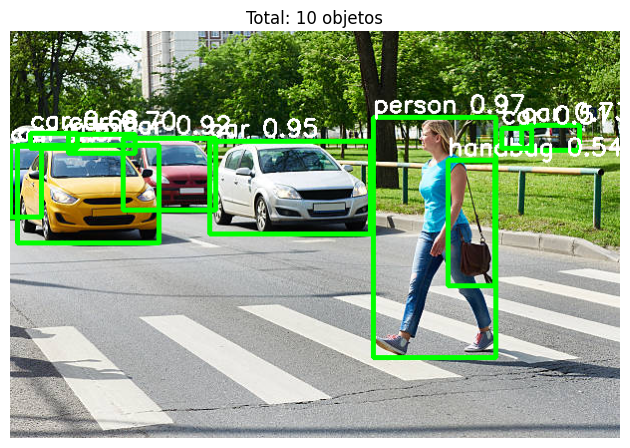

In [24]:
def count_objects_by_class(image, model, conf_threshold=0.5):
    """Cuenta objetos agrupados por clase"""
    
    img_array = np.array(image)
    detections = model.predict(img_array, threshold=conf_threshold)
    
    # Contar por clase (sin Counter)
    class_counts = {}
    for cls in detections.class_id:
        class_name = model.class_names[int(cls)]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
    
    print("objetos:\n")
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count}")
    
    # Dibujar detecciones
    img_result = img_array.copy()
    
    for box, cls, score in zip(detections.xyxy, detections.class_id, detections.confidence):
        x1, y1, x2, y2 = map(int, box)
        class_name = model.class_names[int(cls)]
        
        # Dibujar box y texto
        cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 255, 0), 3)  # Verde
        text = f"{class_name} {score:.2f}"
        cv2.putText(img_result, text, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    
    # Visualizar
    plt.imshow(img_result)
    plt.title(f"Total: {len(detections.class_id)} objetos")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    return class_counts

# Contar objetos en imagen
# counts = count_objects_by_class(image_bananas, coco_model)
counts = count_objects_by_class(image_person, coco_model)

## Ejercicio: Detecta objetos en tu imagen

Prueba el detector con tus propias imagenes. Puede ser:
- Foto de tu escritorio (detectara laptop, mouse, teclado, etc.)
- Foto de la calle (coches, personas, semaforos)
- Cualquier imagen con objetos de COCO

In [8]:
# EJERCICIO: Tu imagen aqui

# Opcion 1: Desde URL
# tu_url = "https://..."  # <- URL de tu imagen
# tu_imagen = Image.open(BytesIO(requests.get(tu_url).content)).convert("RGB")

# Opcion 2: Desde archivo
# tu_imagen = Image.open("ruta/a/tu/imagen.jpg").convert("RGB")

# Detectar
# detect_objects(tu_imagen, coco_model, conf_threshold=0.5)


## Ejercicio Extra: Filtrar por clase

Modifica la funcion `detect_objects()` para que solo muestre detecciones de ciertas clases.

Por ejemplo: solo mostrar "car" y "truck", ignorando el resto.

**Pista**: Filtra las boxes antes de dibujarlas comprobando el nombre de la clase.

In [9]:
# EJERCICIO EXTRA: Deteccion filtrada por clases
def detect_only(image, allowed_classes, conf_threshold=0.5):
    """
    Detecta solo las clases especificadas.
    allowed_classes: lista de nombres de clases, ej: ['car', 'person']
    """
    # Tu codigo aqui...
    pass

# Prueba:
# detect_only(image_cars, allowed_classes=['car'], conf_threshold=0.5)


## Limitaciones de Modelos Supervisados

RF-DETR esta entrenado en COCO que tiene 80 categorias. Esto significa:

### ✅ Detecta bien:
- Objetos comunes: personas, coches, animales, muebles
- Objetos de la vida diaria

### ❌ NO detecta:
- Objetos industriales especificos (tornillos, tuercas, componentes electronicos)
- Objetos raros o muy especializados
- Defectos de fabricacion
- Cualquier cosa que no este en las 80 categorias COCO

**Solucion**: Fine Tuning

# Fine-Tuning: Entrenamiento de Modelo Custom

## ¿Por qué entrenar un modelo custom?

El modelo RF-DETR pre-entrenado en COCO es muy útil, pero tiene limitaciones:

- **COCO es genérico**: Solo detecta "person" sin distinguir roles o contextos específicos
- **Aplicaciones especializadas**: En deportes, seguridad, industria, etc., necesitamos más detalle
- **Clases específicas**: Queremos distinguir entre jugador, árbitro, pelota, etc.

### Ejemplo: Basketball Detection

Vamos a entrenar un modelo custom para detección en baloncesto usando un dataset muy pequeño de **Roboflow Universe**:

**Dataset**: [Basketball Players](https://universe.roboflow.com/roboflow-universe-projects/basketball-players-fy4c2)


## Proceso de Fine-Tuning

El **fine-tuning** consiste en:

1. **Partir del modelo pre-entrenado**: Aprovechamos el conocimiento de COCO (80 clases)
2. **Adaptar a nuestro dominio**: Re-entrenar las capas finales con nuestro dataset específico
3. **Obtener modelo especializado**: Mejor rendimiento en nuestra tarea concreta

**Ventajas**:
- ✅ Requiere menos datos que entrenar desde cero
- ✅ Converge más rápido (menos épocas)
- ✅ Mantiene capacidad de generalización base

**Requisitos**:
- Dataset anotado con bounding boxes (formato COCO, YOLO, etc.)
- Suficientes ejemplos por clase
- GPU para entrenamiento eficiente

In [25]:
if "google.colab" in sys.modules: #Detectamos si estamos en google colab o en local
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path("/content/drive/MyDrive/Modelos_Fundacionales/data/")
else:
    DATA_DIR = Path("./data/")
    
print(DATA_DIR)

data


In [30]:
torch.cuda.empty_cache() # Limpiar memoria GPU antes de entrenamiento
model_custom = RFDETRMedium() 

if (DATA_DIR / "Basketball Players.v1-original_raw-images.coco").exists():
    print("El dataset ya existe.")
else:
    print("El dataset no existe.")

model_custom.train(
    dataset_dir=f"{DATA_DIR}/Basketball Players.v1-original_raw-images.coco",
    epochs=10 # Numero de epochs para entrenar el modelo custom, ponemos 10 para hacerlo rápido
    )

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
El dataset ya existe.
Unable to initialize TensorBoard. Logging is turned off for this session.  Run 'pip install tensorboard' to enable logging.
Not using distributed mode
git:
  sha: 0493353128e2627a95f16454d16d4645934005f4, status: has uncommited changes, branch: main

Namespace(num_classes=10, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=10, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='r

## Carga del Modelo Entrenado y Comparación

Una vez completado el entrenamiento, tenemos un modelo especializado guardado en `output/checkpoint_best_total.pth`.

### Comparación COCO vs Custom

Vamos a comparar cómo funciona el modelo genérico COCO frente a nuestro modelo custom en la misma imagen:

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
{1: 'Ball', 2: 'Hoop', 3: 'Period', 4: 'Player', 5: 'Ref', 6: 'Shot Clock', 7: 'Team Name', 8: 'Team Points', 9: 'Time Remaining'}

Detectados 18 objetos:

  Player: 0.95 en [769, 277, 866, 458]
  Player: 0.95 en [209, 336, 353, 515]
  Player: 0.94 en [914, 277, 994, 449]
  Player: 0.94 en [82, 192, 158, 369]
  Player: 0.92 en [416, 306, 507, 510]
  Player: 0.92 en [538, 115, 623, 300]
  Team Points: 0.91 en [687, 602, 739, 640]
  Ref: 0.90 en [161, 464, 241, 640]
  Player: 0.89 en [425, 222, 499, 395]
  Ref: 0.88 en [928, 81, 984, 237]
  Player: 0.86 en [48, 38, 130, 209]
  Team Points: 0.86 en [537, 602, 591, 642]
  Time Remaining

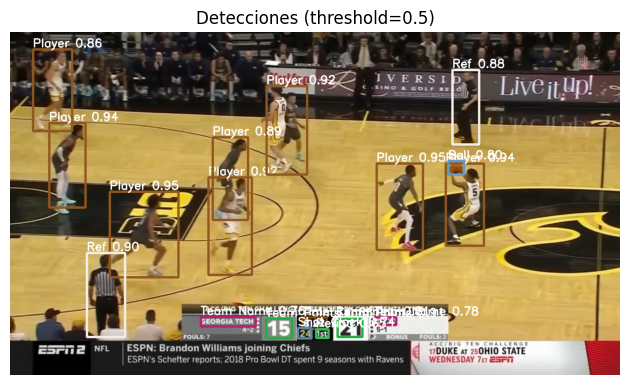

In [31]:
model_predict = RFDETRMedium(pretrain_weights="output/checkpoint_best_total.pth")
image_path = f"{DATA_DIR}/Basketball Players.v1-original_raw-images.coco/test/youtube-15_jpg.rf.22a08fb220872e38ed069f28024679e0.jpg"
custom_image = Image.open(image_path).convert("RGB")

# detect_objects(custom_image, coco_model, conf_threshold=0.5)
print(model_predict.class_names)
detect_objects(custom_image, model_predict, conf_threshold=0.5)

## Resumen

En este notebook hemos aprendido:

✅ Que es la deteccion de objetos y para que sirve  
✅ Diferencia entre arquitecturas clasicas (YOLO) y modernas (RF-DETR)  
✅ Por que Transformers funcionan bien en vision  
✅ Usar RF-DETR para detectar objetos  
✅ Configurar thresholds de confianza  
✅ Limitaciones de modelos supervisados (numero de clases)  
✅ Contar objetos automaticamente   
✅ Descargar y usar datasets de Roboflow Universe  
✅ Proceso de fine-tuning: partir de modelo pre-entrenado y adaptar  
✅ Entrenar RF-DETR con dataset custom (Basketball Players)